In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/madhavkhanal/titanic/train.csv


# EDA using bivariate and multivariate analysis

Bivariate analysis examines the relationship between exactly two variables to see if a change in one is associated with a change in the other while multivariate analysis explores the interaction between three or more variables simultaneously to uncover complex patterns and dependencies.

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
tips= sns.load_dataset('tips')

In [4]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# 1.Scatterplot(Numerical-Numerical)

**Bivariate Analysis**

<Axes: xlabel='total_bill', ylabel='tip'>

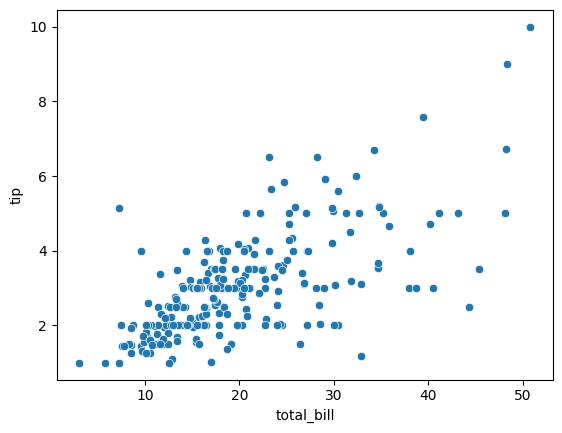

In [5]:
sns.scatterplot(x =tips['total_bill'],y = tips['tip'])

There is a postive correlation or linear relation  between the two variables.As the total_bill variable increases , the tip amount generally increases as well.T

**MutliVariate analyis**

<Axes: xlabel='total_bill', ylabel='tip'>

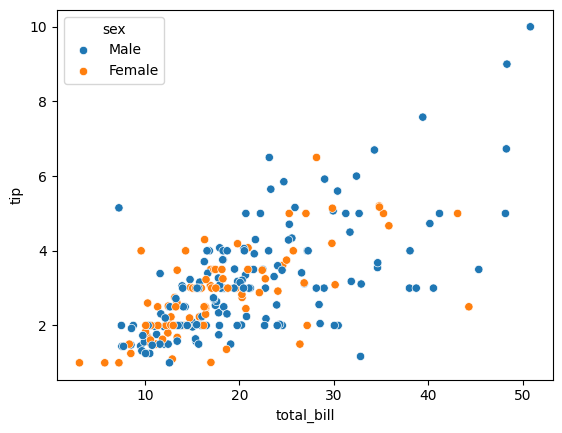

In [6]:
sns.scatterplot(x=tips['total_bill'],y=tips['tip'], hue=tips['sex'])

As we already know ,there is a linear relation between two variable-tip and total bill.By performing mutlivariate analysis,we know that the tip figure of men are higher than that of  female.As a result,men give more tips than female.

<Axes: xlabel='total_bill', ylabel='tip'>

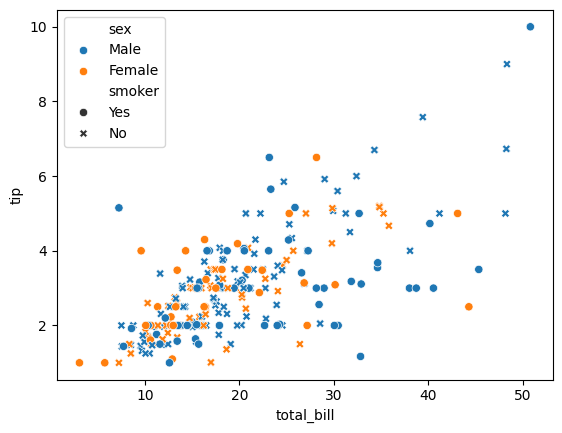

In [7]:
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'],style=tips['smoker'])

As we see non-smoker male gives more tips than other one.

# 2.Barplot (Numerical-Categorical)
A bar plot is used to represent relationship between numerical and categorical variable.It shows the central tendency of a numerical value for each category

In [8]:
titanic = pd.read_csv('/kaggle/input/datasets/madhavkhanal/titanic/train.csv')

In [9]:
titanic.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
474,475,0,3,"Strandberg, Miss. Ida Sofia",female,22.0,0,0,7553,9.8375,NaN,S
40,41,0,3,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.0,1,0,7546,9.4750,NaN,S
207,208,1,3,"Albimona, Mr. Nassef Cassem",male,26.0,0,0,2699,18.7875,NaN,C
690,691,1,1,"Dick, Mr. Albert Adrian",male,31.0,1,0,17474,57.0000,B20,S
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.3500,NaN,Q


<Axes: xlabel='Pclass', ylabel='Fare'>

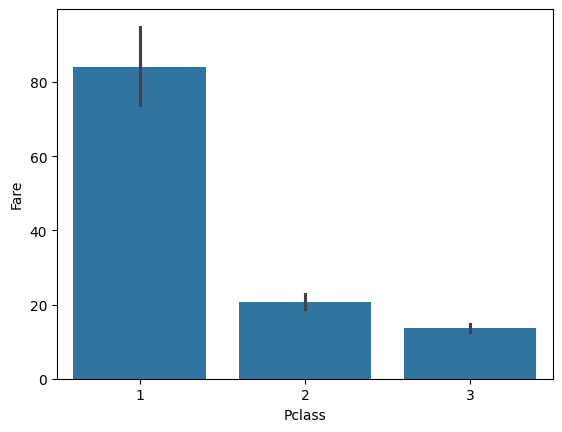

In [10]:
sns.barplot(x=titanic['Pclass'],y=titanic['Fare'])

The barplot illustrates the average fare  for each Pclass in the titanic ship.

# 3.Boxplot (Numerical - Categorical)
A Box Plot is a standardized way of displaying the distribution of data based on a five-number summary.
<br>
A box plot breaks down our data into quartiles:
<br>
**Minimum:** The lowest data point (excluding outliers).<br>
**First Quartile (Q1 / 25th Percentile)**: 25% of the data falls below this line.<br>
**Median (Q2 / 50th Percentile)**: The middle value of the dataset. It shows the "center" of the data.<br>
**Third Quartile (Q3 / 75th Percentile)**: 75% of the data falls below this line.<br>
**Maximum:** The highest data point (excluding outliers).<br>
**Outliers:** Individual points plotted outside the whiskers.

<Axes: xlabel='Sex', ylabel='Age'>

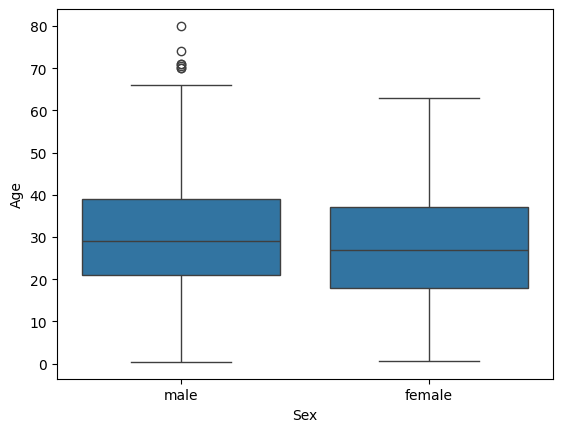

In [11]:
sns.boxplot(x=titanic['Sex'],y =titanic['Age'])

The median age for males is slightly higher (approx. 29) compared to females (approx. 27)<br>
The male distribution features several high-age outliers (70–80 years), whereas the female distribution has no outliers

# 4.HeatMap (Categorical-Categorical)
A heatmap is used to represent relationship between categorical variables.

<Axes: xlabel='Survived', ylabel='Pclass'>

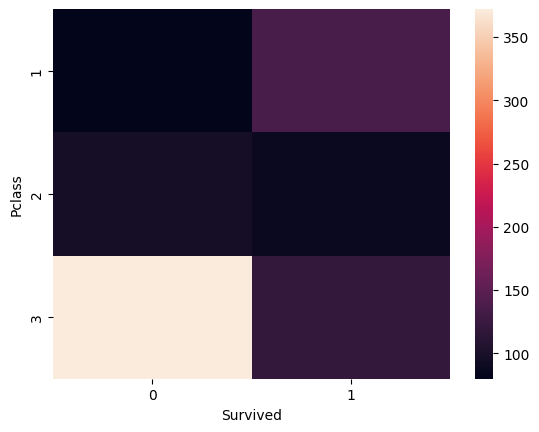

In [12]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived']))

The heatmap shows that more passengers travelling in Pclass 3  died  than in the other two classes.

In [16]:
titanic.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64